### 項目名稱

    華盛頓州電動車 (EV) 用戶行為分析計畫


### 項目背景

    隨著全球減碳趨勢與政府補助政策推行，電動車市場進入高速成長期。
    本項目利用華盛頓州政府公開的電動車註冊數據（包含 28 萬筆以上的車輛紀錄），旨在分析現有市場分布。
    期望藉由數據量化各郡的充電潛在需求，為地區性充電設施的策略性佈建提供決策參考。


### 欄位說明

1. 基礎識別與地理資訊
   
**`VIN (1-10)`**：車輛識別碼的前 10 碼。

**`County (縣)`**：車主居住的縣（例如: King County 是西雅圖所在地)。

**`City (城市)`**： 車主居住的城市。

**`State (州)`**： 此份資料大多是 WA (華盛頓州)，有少許外州的資料。

**`Postal Code (郵遞區號)`**： 比城市更細的地理單位。

**`Vehicle Location`**： 地理座標 (經緯度)。

2. 車輛產品資訊
   
**`Model Year (年份)`**： 車輛的生產年份。

**`Make (品牌)`**： 例如 TESLA, NISSAN, FIAT。

**`Model (車型)`**： 例如 MODEL 3, LEAF, 500E。

**`Electric Vehicle Type`**： 分為 BEV (純電動車) 與 PHEV (插電式混合動力)。

3. 技術規格與政策 

**`Clean Alternative Fuel Vehicle (CAFV) Eligibility`**： 是否符合乾淨能源車補助資格。

**`Electric Range (續航里程)`**： 充滿電能跑多少英里。

**`Base MSRP`**： 建議零售價。

4. 行政與電力資訊 (歸誰管？)

**`Legislative District (立法區)`**： 政治選區。

**`DOL Vehicle ID`**： 交通局 (Department of Licensing) 給這台車的唯一 ID。

**`Electric Utility`**： 該車輛所在地的電力公司。

**`2020 Census Tract`**： 2020 年人口普查統計區段。



In [72]:
#載入套件並讀取檔案
import pandas as pd
import numpy as np

file_path = "./Electric_Vehicle_Population_Data.csv"
df= pd.read_csv(file_path)

In [73]:
#了解資料欄、列的數量
df.shape

(280833, 16)

In [3]:
#看前五筆資料
df.head(5)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,1N4AZ0CP6D,King,Kirkland,WA,98034.0,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75.0,1.0,154635729,POINT (-122.22901 47.72201),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
1,5YJ3E1EC8L,Kitsap,Bainbridge Island,WA,98110.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,308.0,23.0,107518645,POINT (-122.521 47.62759),PUGET SOUND ENERGY INC,5.303509e+10
2,5YJ3E1EBXJ,King,Seattle,WA,98144.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,37.0,474808813,POINT (-122.30866 47.57874),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,ZFAFFAC45R,Thurston,Yelm,WA,98597.0,2024,FIAT,500E,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,2.0,273658514,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
4,5YJYGDEE3L,King,Kent,WA,98030.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,47.0,109579900,POINT (-122.19975 47.37483),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


In [4]:
df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 280833 entries, 0 to 280832
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         280833 non-null  str    
 1   County                                             280821 non-null  str    
 2   City                                               280821 non-null  str    
 3   State                                              280833 non-null  str    
 4   Postal Code                                        280821 non-null  float64
 5   Model Year                                         280833 non-null  int64  
 6   Make                                               280833 non-null  str    
 7   Model                                              280833 non-null  str    
 8   Electric Vehicle Type                              280833 non-null  str    
 9   Clea

In [6]:
df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,280821.000000,280833.000000,280821.000000,280130.000000,2.808330e+05,2.808210e+05
mean,98175.409538,2022.111643,38.757846,28.819352,2.470600e+08,5.297039e+10
std,2591.070456,3.064528,77.903581,14.907410,6.325326e+07,1.654845e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.240730e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.642395e+08,5.303303e+10
75%,98382.000000,2024.000000,32.000000,42.000000,2.803006e+08,5.305394e+10
max,99517.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


### 資料健康狀況診斷：
    
    1.缺失值 (Nulls)：`County`、`City`、`Postal Code`、`Electric Range` 都少了 12 筆資料（280833 vs 280821）。
    通常是因為這些車輛註冊在華盛頓州以外。

    2.型態轉換：`Postal Code` 應該是郵遞區號，但現在是 float64，應該轉成字串或整數。

    3.核心欄位檢查：`Electric Range`(電動車續航里程)有缺失值，這會影響我們算「平均續航力」。
    

In [7]:
#進行資料清洗前,先備份,不要動到原始資料
df_clean = df.copy()

In [8]:
#先看缺失值數量
df_clean .isnull().sum()

VIN (1-10)                                             0
County                                                12
City                                                  12
State                                                  0
Postal Code                                           12
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        12
Legislative District                                 703
DOL Vehicle ID                                         0
Vehicle Location                                      20
Electric Utility                                      12
2020 Census Tract                                     12
dtype: int64

In [9]:
# 想觀察的欄位清單
target_cols = ['County', 'City', 'Postal Code', 'Electric Range']

# 篩選出這些欄位中「任何」含有 null 的 rows
null_data = df_clean[df_clean[target_cols].isnull().any(axis=1)]

#秀出資料
print(f"這四個欄位中含有缺失值的資料總共有：{len(null_data)} 筆")
display(null_data)

這四個欄位中含有缺失值的資料總共有：24 筆


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
398,7SAYGDEE9N,NaN,NaN,BC,NaN,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,NaN,224286394,NaN,NaN,NaN
19041,W1KRJ8CB3T,Clark,Vancouver,WA,98682.0,2026,MERCEDES-BENZ,AMG GT,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,NaN,17.0,286644949,POINT (-122.55149 45.69345),BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...,5.301104e+10
21054,ZHWUC1ZM5S,King,Seattle,WA,98125.0,2025,LAMBORGHINI,REVUELTO,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,NaN,46.0,282538896,POINT (-122.30253 47.72656),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
62784,W1K6G8CB4T,King,Sammamish,WA,98075.0,2026,MERCEDES-BENZ,S-CLASS,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,NaN,41.0,290101094,POINT (-122.03539 47.61344),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
109791,ZHWUC1ZM5S,Snohomish,Snohomish,WA,98296.0,2025,LAMBORGHINI,REVUELTO,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,NaN,1.0,277331204,POINT (-122.1389 47.87115),PUGET SOUND ENERGY INC,5.306105e+10
133099,ZHWUC1ZM3S,King,Mercer Island,WA,98040.0,2025,LAMBORGHINI,REVUELTO,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,NaN,41.0,279110842,POINT (-122.21238 47.57816),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
137176,W1K6G8CB1T,King,Fall City,WA,98024.0,2026,MERCEDES-BENZ,S-CLASS,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,NaN,5.0,288348770,POINT (-121.89086 47.56812),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
144615,ZHWUC1ZM5S,King,Sammamish,WA,98075.0,2025,LAMBORGHINI,REVUELTO,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,NaN,41.0,287644927,POINT (-122.03539 47.61344),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
160313,W1K6G8CB0T,King,Vashon,WA,98070.0,2026,MERCEDES-BENZ,S-CLASS,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,NaN,34.0,285597938,POINT (-122.4573 47.44929),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
187350,5YJ3E1EA1J,NaN,NaN,QC,NaN,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,NaN,245011189,NaN,NaN,NaN


### 資料清洗紀錄 - 缺失值處理

    1. 排除非華盛頓州資料
    現象： 發現 12 筆資料的 County 與 City 為空值。
    原因： 經檢查其 State 欄位為 BC (加拿大)、AE (海外軍事基地) 等，不屬於本研究（華盛頓州電動車）的地理分析範圍。
    處理： 予以刪除，優先確保數據的完整性。



    2. 處理核心技術參數缺失
    現象： 部分 2025-2026 年新款車型（如 Mercedes-Benz, Lamborghini）的 Electric Range 為 Null 共有12筆。
    原因： 此類新上市或特定高性能車款可能尚未錄入官方續航里程數據。由於這些缺失值會干擾里程分佈分析與平均值計算，且數量極少（佔總量不到 0.01%）。
    處理： 予以刪除，優先確保數據的完整性。


    3. 提升資料一致性
    處理： 使用 dropna(subset=["欄名"]) 針對地理與技術關鍵欄位進行清洗，確保後續視覺化（地圖、里程分佈圖）不會報錯。


In [10]:
target_cols = ['County', 'City', 'Postal Code', 'Electric Range']

# 以上四欄只要有缺失值 就執行刪除
df_clean = df_clean.dropna(subset=target_cols)

# 清洗後的資料筆數
df_clean.shape

(280809, 16)

In [11]:
#再看一下 null 還剩多少
df_clean .isnull().sum()

VIN (1-10)                                             0
County                                                 0
City                                                   0
State                                                  0
Postal Code                                            0
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Legislative District                                 691
DOL Vehicle ID                                         0
Vehicle Location                                       8
Electric Utility                                       0
2020 Census Tract                                      0
dtype: int64

### 資料清洗紀錄 - 缺失值處理

    Legislative District (政治選區) 還有 691 筆缺失。
    因為資料量有點大，不宜全部刪除，故將選區的缺失值補上 "Unknown"。

    Vehicle Location (車輛經緯度) 還有 8 筆缺失值。
    數量很小，我選擇直接刪除，避免後續畫地圖報錯。
    

In [12]:
df_clean["Legislative District"] = df_clean["Legislative District"].fillna("Unknown")

df_clean = df_clean.dropna(subset=["Vehicle Location"])

In [13]:
df_clean .isnull().sum()

VIN (1-10)                                           0
County                                               0
City                                                 0
State                                                0
Postal Code                                          0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Legislative District                                 0
DOL Vehicle ID                                       0
Vehicle Location                                     0
Electric Utility                                     0
2020 Census Tract                                    0
dtype: int64

到目前為止看起來沒有缺失值了！

### 資料型態轉正

In [14]:
# Postal Code 轉為 str
df_clean["Postal Code"] = df_clean["Postal Code"].astype(str)

# Legislative District 轉為 str
df_clean["Legislative District"] = df_clean["Legislative District"].astype(str)

In [15]:
# 確認資料型態
df_clean.info()

<class 'pandas.DataFrame'>
Index: 280801 entries, 0 to 280832
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         280801 non-null  str    
 1   County                                             280801 non-null  str    
 2   City                                               280801 non-null  str    
 3   State                                              280801 non-null  str    
 4   Postal Code                                        280801 non-null  str    
 5   Model Year                                         280801 non-null  int64  
 6   Make                                               280801 non-null  str    
 7   Model                                              280801 non-null  str    
 8   Electric Vehicle Type                              280801 non-null  str    
 9   Clean Alt

In [16]:
# 計算數值型欄位的統計摘要：包含計數、平均值、標準差、最小值、四分位數與最大值
df_clean.describe()

,Model Year,Electric Range,DOL Vehicle ID,2020 Census Tract
count,280801.000000,280801.000000,2.808010e+05,2.808010e+05
mean,2022.111595,38.757839,2.470594e+08,5.297039e+10
std,3.064422,77.903639,6.325557e+07,1.654904e+09
min,1999.000000,0.000000,4.385000e+03,1.001020e+09
25%,2021.000000,0.000000,2.240724e+08,5.303301e+10
50%,2023.000000,0.000000,2.642412e+08,5.303303e+10
75%,2024.000000,32.000000,2.803000e+08,5.305394e+10
max,2027.000000,337.000000,4.791150e+08,6.601095e+10


In [17]:
#檢視資料內不同洲別有哪些＆各是幾筆
print(df_clean['State'].value_counts())

State
WA    280111
CA       169
VA        88
FL        46
MD        45
TX        40
OR        27
CO        25
AZ        21
IL        18
NV        18
NC        17
NY        15
GA        14
MO        12
SC         9
AL         8
PA         8
NJ         8
MI         8
KY         7
RI         7
MA         7
KS         6
ID         6
LA         5
TN         5
CT         5
OH         5
DC         4
NE         4
WI         4
IN         3
NH         3
NM         3
WY         2
UT         2
HI         2
OK         2
IA         2
MN         2
ME         2
AR         2
SD         1
GU         1
MS         1
AK         1
Name: count, dtype: int64


### 資料清洗紀錄 - 範圍鎖定

    處理：過濾掉非華盛頓州 (WA) 的資料。
    原因：非 WA 樣本數極低（合計佔比小於 0.2%），不足以代表該州母體，且本研究目標聚焦於華盛頓州市場分析，納入外州資料恐造成統計偏差與干擾視覺化呈現。

In [18]:
#只留 State = WA的資料
df_clean = df_clean[df_clean["State"] == "WA"]

In [19]:
#看下是否只剩華盛頓州的資料
df_clean['State'].value_counts()

State
WA    280111
Name: count, dtype: int64

In [20]:
print(df_clean['Make'].value_counts().head(10))

Make
TESLA         114465
CHEVROLET      19379
NISSAN         16132
FORD           15389
KIA            14083
TOYOTA         11938
BMW            11622
HYUNDAI        10556
RIVIAN          8929
VOLKSWAGEN      7496
Name: count, dtype: int64


## Part 1: 華盛頓州電動車市場概況

### A.品牌市佔率分析 (Top 10)

/var/folders/hj/ftk7jsjd1v3gkr1sbsdgxdkm0000gn/T/ipykernel_4238/1303927289.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_makes.values, y=top_makes.index, palette="viridis")


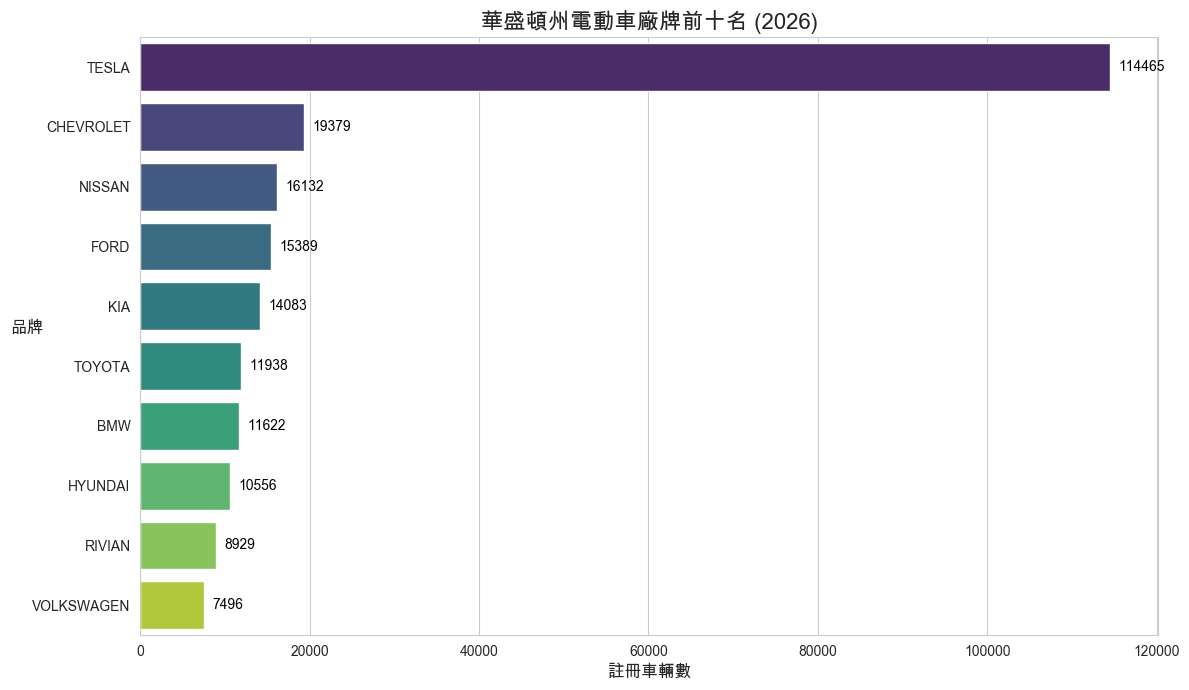

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 先設定 seaborn 風格
sns.set_style("whitegrid")

# 2. 設定中文字型 (必須在 sns.set_style 之後，才能覆蓋其預設)
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False 

# 3. 開始繪圖
plt.figure(figsize=(12, 7))

# 準備數據
top_makes = df_clean['Make'].value_counts().head(10)

# 畫圖
sns.barplot(x=top_makes.values, y=top_makes.index, palette="viridis")

# 4. 增加標籤與標題
plt.title('華盛頓州電動車廠牌前十名 (2026)', fontsize=16, fontweight='bold')
plt.xlabel('註冊車輛數', fontsize=12)
plt.ylabel('品牌',rotation=0, fontsize=12)

# 在長條圖旁邊加上數字
for i, v in enumerate(top_makes.values):
    plt.text(v + 1000, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### B.地理分佈分析 (County / City)

特斯拉在ＷＡ州佔比為 40.86 %


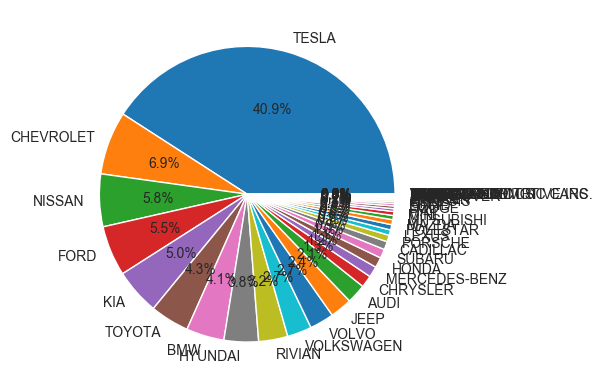

In [22]:
# WA 州內的特斯拉總數
tesla_count_wa = df_clean[df_clean['Make'] == 'TESLA'].shape[0]
# WA 州內的電動車總數
total_wa_ev = df_clean.shape[0]
print(f"特斯拉在ＷＡ州佔比為 {tesla_count_wa*100 / total_wa_ev:.2f} %")

plt.pie(df['Make'].value_counts(), labels = df['Make'].value_counts().index ,autopct='%.1f%%' )
plt.show()

### B 前面圓餅圖分得太細，合併細項，重新畫圖

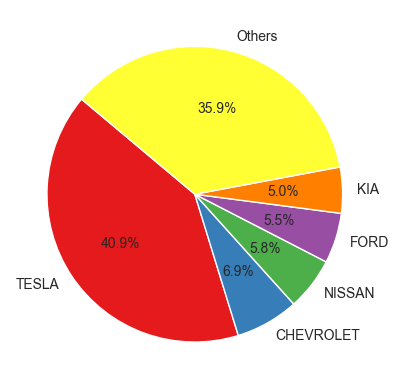

In [40]:
# 1. 計算所有品牌的數量
make_counts = df_clean['Make'].value_counts()

# 2. 取出前 5 名
top_5 = make_counts.head(5)

# 3. 將剩下的全部加總為 "Others"
others_count = make_counts.iloc[5:].sum()
others = pd.Series({'Others': others_count})

# 4. 合併成新的繪圖資料
pie_plot_data = pd.concat([top_5, others])

# 5. 畫圖
plt.pie(pie_plot_data,
        labels = pie_plot_data.index,
        autopct='%.1f%%',
        startangle = 140, # 旋轉角度讓圖看起來更平衡
        colors = plt.cm.Set1.colors) # 使用配色盤讓顏色更有層次)
plt.show()

In [24]:
pie_plot_data

TESLA        114465
CHEVROLET     19379
NISSAN        16132
FORD          15389
KIA           14083
Others       100663
dtype: int64

## 經由探索性資料分析EDA

1. 「特斯拉」的絕對統治力
TESLA (114,465) 的數量是第二名 CHEVROLET (19,379) 的 5.8 倍。在華盛頓州，路上每 2.5 台電動車，可能就有 1 台是特斯拉。

2. 傳統車廠的追趕
CHEVROLET 和 NISSAN 穩坐二、三名，這主要歸功於較早進入市場的平價車款（如 Chevy Bolt 和 Nissan LEAF）。
FORD 和 KIA 緊隨其後，反映出野馬 Mach-E 和 KIA EV6 等新世代車款正在發力。

3. 新創品牌的崛起
特別注意第 9 名的 RIVIAN (8,929)。作為一個只生產高價電動皮卡和 SUV 的新品牌，它的數量竟然超過了老牌大廠 VOLKSWAGEN，這顯示華盛頓州的消費者對於戶外冒險車款（Electric Adventure Vehicles）有很強的需求。

### C.華盛頓州內的特斯拉型號分佈

In [25]:
# 看看特斯拉內部的型號分布
tesla_models = df_clean[df_clean['Make'] == 'TESLA']['Model'].value_counts()
print(tesla_models)

Model
MODEL Y       60184
MODEL 3       37708
MODEL S        7709
MODEL X        6921
CYBERTRUCK     1897
ROADSTER         46
Name: count, dtype: int64


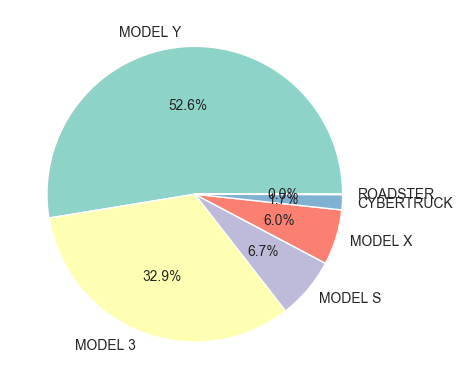

In [26]:
#  華盛頓州,特斯拉不同型號佔比
plt.pie(tesla_models, labels = tesla_models.index ,autopct='%.1f%%',colors = plt.cm.Set3.colors )
plt.show()

### D.華盛頓州電動車數量前五大縣

In [27]:
# 看看哪個郡是電動車的聖地
county_counts = df_clean['County'].value_counts().head(5)

print("華盛頓州電動車數量前五大縣：")
print(county_counts)

華盛頓州電動車數量前五大縣：
County
King         138268
Snohomish     35136
Pierce        23040
Clark         17301
Thurston      10220
Name: count, dtype: int64


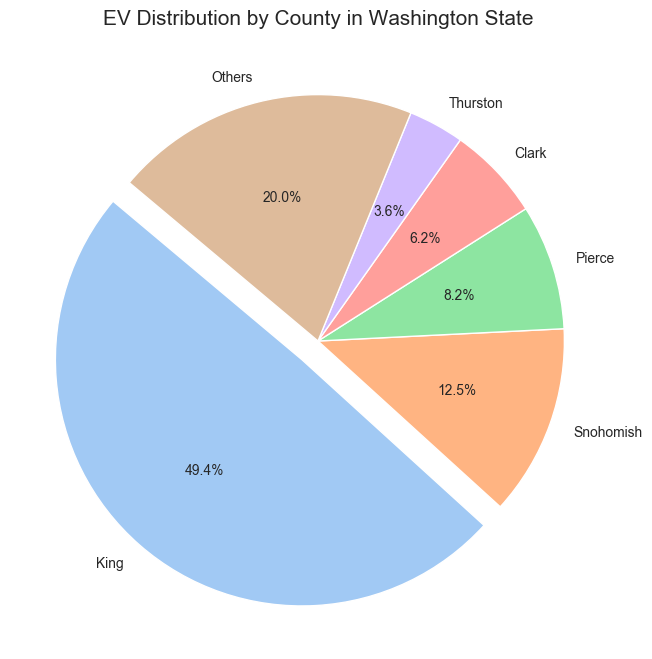

In [28]:
# 準備數據：前五名與「其他」
county_counts = df_clean['County'].value_counts()
top_5 = county_counts.head(5)
others = pd.Series({'Others': county_counts.iloc[5:].sum()})
plot_data = pd.concat([top_5, others])

# 畫圓餅圖
plt.figure(figsize=(10, 8))
plot_data.plot(kind='pie', autopct='%1.1f%%', startangle=140,
               colors=sns.color_palette("pastel"), explode=[0.1, 0, 0, 0, 0, 0])
plt.title('EV Distribution by County in Washington State', fontsize=15, fontweight='bold')
plt.ylabel('') # 隱藏 Y 軸標籤讓圖更好看
plt.show()

In [29]:
# 看看龍頭縣的品牌分布
king_county_makes = df_clean[df_clean['County'] == 'King']['Make'].value_counts().head(5)
print("King County 最受歡迎品牌：")
print(king_county_makes)

King County 最受歡迎品牌：
Make
TESLA        59872
CHEVROLET     7730
NISSAN        7561
BMW           6782
KIA           6250
Name: count, dtype: int64


### E.華盛頓州電動車類型佔比

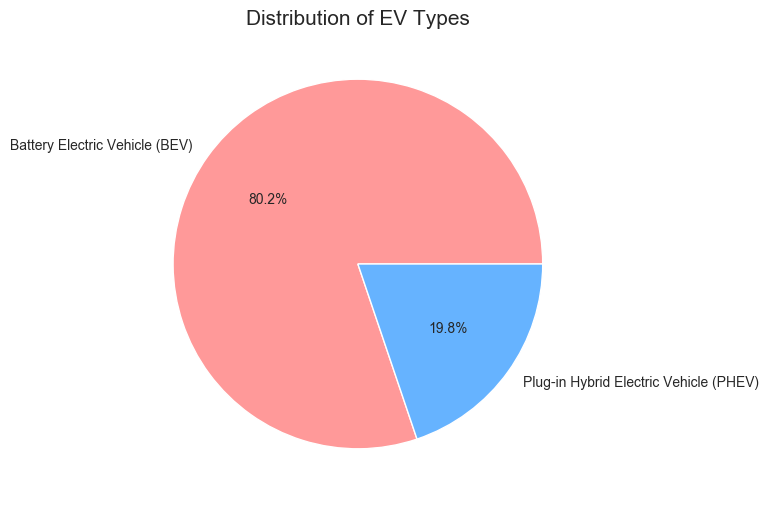

In [30]:
# 計算電動車類型分佈
ev_type_counts = df_clean['Electric Vehicle Type'].value_counts()

# 畫圓餅圖
plt.figure(figsize=(8, 6))
ev_type_counts.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Distribution of EV Types', fontsize=15, fontweight='bold')
plt.ylabel('')
plt.show()

## F. 華盛頓州電動車成長幅度(2000-2024)

Text(0.5, 1.0, '華盛頓州電動車普及趨勢（截至 2024 年之完整數據）')

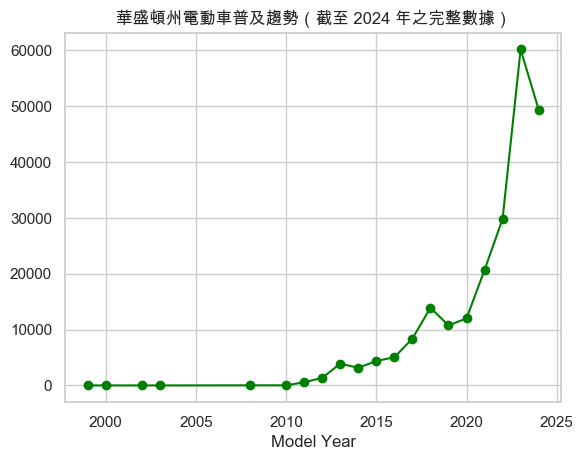

In [48]:
# 只畫到 2024 年，濾掉那些不完整的年份
df_complete = df_clean[df_clean['Model Year'] <= 2024]
df_complete['Model Year'].value_counts().sort_index().plot(kind='line', marker='o', color='green')
plt.title('華盛頓州電動車普及趨勢（截至 2024 年之完整數據）')

## 圖表洞察：
此圖表顯示電動車登記數於 2023 年達到高峰後呈現下滑。需特別注意，此數據反映的是「登記年份」，而非單純的「銷售年份」。2025 及 2026 年之數據因統計時間尚未結束，呈現斷崖式下跌屬資料截斷效應，但不代表市場需求衰退。

In [49]:
# 經緯度資料欄位處理

import pandas as pd

# 移除 POINT( ) 並用空格切割
def extract_lat(loc):
    try:
        # 字串處理：取出 (-122.33 47.60) 裡面的數字
        parts = loc.replace('POINT (', '').replace(')', '').split()
        return float(parts[1]) # 緯度通常是第二個數字
    except:
        return None

def extract_lon(loc):
    try:
        parts = loc.replace('POINT (', '').replace(')', '').split()
        return float(parts[0]) # 經度是第一個數字
    except:
        return None

# 產生新的經緯度欄位
df_clean['lat'] = df_clean['Vehicle Location'].apply(extract_lat)
df_clean['lon'] = df_clean['Vehicle Location'].apply(extract_lon)

# 刪除處理過程中產生的 Null 值
df_map = df_clean.dropna(subset=['lat', 'lon'])

In [50]:
# 測試一下前 5 筆經緯度
print(df_clean[['lat', 'lon']].head())

        lat        lon
0  47.72201 -122.22901
1  47.62759 -122.52100
2  47.57874 -122.30866
3  46.94239 -122.60735
4  47.37483 -122.19975


### G. 華盛頓州電動車各郡數量分佈圖

In [56]:
import folium
# 1. 建立各縣市的聚合數據 (統計總數 + 找中心經緯度)
county_summary = df_clean.groupby('County').agg({
    'lat': 'mean',
    'lon': 'mean',
    'VIN (1-10)': 'count' # 算一下這個縣有多少車
}).rename(columns={'VIN (1-10)': 'car_count'})

# 2. 建立地圖
m = folium.Map(location=[47.4, -120.5], zoom_start=7)

# 3. 畫出每一個縣的圈圈 (圈圈越大，車越多)
for idx, row in county_summary.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=row['car_count'] / 5000, # 調整這個除數來控制圈圈大小
        popup=f"{idx}: {row['car_count']} cars",
        color='blue',
        fill=True,
        fill_color='blue'
    ).add_to(m)

m

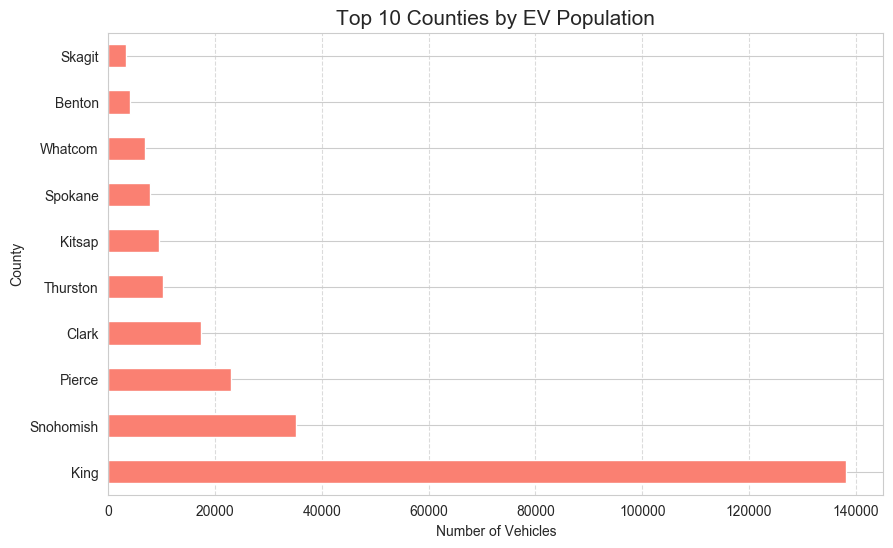

In [38]:
# 畫出縣市分布排行榜 
county_counts = df_clean['County'].value_counts().head(10)

plt.figure(figsize=(10, 6))
county_counts.plot(kind='barh', color='salmon')
plt.title('Top 10 Counties by EV Population', fontsize=15)
plt.xlabel('Number of Vehicles')
plt.ylabel('County')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 根據電動車的「續航里程」與「出廠年份」進行分群（K-Means Clustering），
## 並計算各群組在續航能力上的平均表現差異。

In [58]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. 讀取資料
file_path = "./Electric_Vehicle_Population_Data.csv"
df = pd.read_csv(file_path)

# 2. 選取欄位並處理缺失值
df = df[df['Electric Range'] > 0 ]
data = df[['Electric Range', 'Model Year']].dropna()

# 3. 標準化數據 
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# 4. 進行分群 (分 3 類)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Category'] = kmeans.fit_predict(scaled_data)

# 5. 查看結果
print(df.groupby('Category')['Electric Range'].mean())

Category
0     50.793632
1     31.612902
2    231.077700
Name: Electric Range, dtype: float64


In [59]:
print(f"DataFrame 的長度: {len(df)}")

DataFrame 的長度: 101283


### 分群結果解讀 

第 0 群 (平均約 50.8 km)：這是長程插電式混合動力車或早期電動車。續航力稍微比第一群好一些，但仍未達到長途駕駛的門檻。

第 1 群 (平均約 31.6 km)：這是典型的短程插電式混合動力車 (PHEV)。它們的純電行駛能力有限，主要作為市區短程代步用。

第 2 群 (平均約 231.1 km)：這是純電動車 (BEV) 的主力群體。它們具備顯著的里程優勢，是執行長途移動的核心車種。

In [60]:
print(pd.crosstab(df['Make'], df['Category']))

Category                 0     1      2
Make                                   
ALFA ROMEO               0   104      0
AUDI                   522  1512    836
AZURE DYNAMICS           3     0      0
BENTLEY                  0     9      0
BMW                   2560  4184    304
CADILLAC                87     0      0
CHEVROLET             4639     0   5209
CHRYSLER               756  2928      0
DODGE                    0   712      0
FIAT                   731     0      0
FISKER                  10     0      0
FORD                  3201   906      0
HONDA                  748   113      0
HYUNDAI                181  1102    337
JAGUAR                   0     0    109
JEEP                     0  6569      0
KIA                   1076  3797    852
LAMBORGHINI              0    19      0
LAND ROVER               0   229      0
LEXUS                    0  1009      0
LINCOLN                  0   450      0
MAZDA                    0  1523      0
MERCEDES-BENZ          293  1009      0


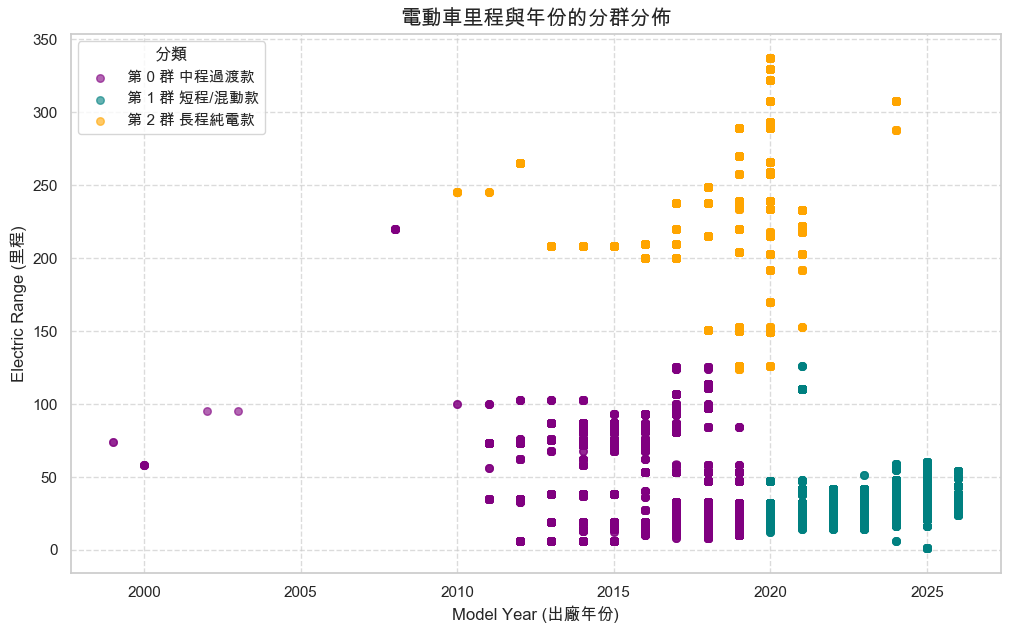

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# 定義類別名稱 
category_names = {0: '第 0 群 中程過渡款', 1: '第 1 群 短程/混動款', 2: '第 2 群 長程純電款'}
colors = ['purple', 'teal', 'orange'] 

for i in range(3):
    # 篩選出該類別的數據
    subset = df[df['Category'] == i]
    plt.scatter(subset['Model Year'], subset['Electric Range'], 
                c=colors[i], label=category_names[i], alpha=0.6, s=30)

plt.xlabel('Model Year (出廠年份)', fontsize=12)
plt.ylabel('Electric Range (里程)', fontsize=12)
plt.title('電動車里程與年份的分群分佈', fontsize=15)

# 加入圖例
plt.legend(title="分類")

# 加入網格，讓閱讀更容易
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

### 離群值觀察

In [70]:
# 找出年份較早 (例如 2010 年前) 且里程數很高 (例如超過 150 公里) 的車
pioneers = df[(df['Model Year'] < 2010) & (df['Electric Range'] > 150)]

# 將它們按年份從小到大排序，看看最早出現的是哪一台
pioneers = pioneers.sort_values(by='Model Year', ascending=True)

# 顯示前幾名
print("這些是當時的里程先驅車款：")
print(pioneers[['Make', 'Model', 'Model Year', 'Electric Range']].head(10))

這些是當時的里程先驅車款：
         Make     Model  Model Year  Electric Range
7907    TESLA  ROADSTER        2008           220.0
243291  TESLA  ROADSTER        2008           220.0
234035  TESLA  ROADSTER        2008           220.0
206758  TESLA  ROADSTER        2008           220.0
205745  TESLA  ROADSTER        2008           220.0
202094  TESLA  ROADSTER        2008           220.0
186468  TESLA  ROADSTER        2008           220.0
185726  TESLA  ROADSTER        2008           220.0
166943  TESLA  ROADSTER        2008           220.0
166930  TESLA  ROADSTER        2008           220.0
